In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.datasets import load_digits
from sklearn import datasets
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as tt

In [2]:
class Digits(Dataset):
    """Scikit-Learn Digits dataset."""

    def __init__(self, mode='train', transforms=None):
        digits = load_digits()
        if mode == 'train':
            self.data = digits.data[:1000].astype(np.float32)
        elif mode == 'val':
            self.data = digits.data[1000:1350].astype(np.float32)
        else:
            self.data = digits.data[1350:].astype(np.float32)

        self.transforms = transforms

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        if self.transforms:
            sample = self.transforms(sample)
        return sample

Distributions

In [3]:
PI = torch.from_numpy(np.asarray(np.pi))
EPS = 1.e-7

def log_categorical(x, p, num_classes=256, reduction=None, dim=None):
    x_one_hot = F.one_hot(x.long(), num_classes=num_classes)
    log_p = x_one_hot * torch.log(torch.clamp(p, EPS, 1. - EPS))
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p

def log_bernoulli(x, p, reduction=None, dim=None):
    pp = torch.clamp(p, EPS, 1. - EPS)
    log_p = x * torch.log(pp) + (1. - x) * torch.log(1. - pp)
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p

def log_normal_diag(x, mu, log_var, reduction=None, dim=None):
    log_p = -0.5 * torch.log(2. * PI) - 0.5 * log_var - 0.5 * torch.exp(-log_var) * (x - mu)**2.
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p

def log_standard_normal(x, reduction=None, dim=None):
    log_p = -0.5 * torch.log(2. * PI) - 0.5 * x**2.
    if reduction == 'avg':
        return torch.mean(log_p, dim)
    elif reduction == 'sum':
        return torch.sum(log_p, dim)
    else:
        return log_p

# Chakraborty & Chakravarty, "A new discrete probability distribution with integer support on (−∞, ∞)",
#  Communications in Statistics - Theory and Methods, 45:2, 492-505, DOI: 10.1080/03610926.2013.830743

def log_min_exp(a, b, epsilon=1e-8):
    """
    Source: https://github.com/jornpeters/integer_discrete_flows
    Computes the log of exp(a) - exp(b) in a (more) numerically stable fashion.
    Using:
    log(exp(a) - exp(b))
    c + log(exp(a-c) - exp(b-c))
    a + log(1 - exp(b-a))
    And note that we assume b < a always.
    """
    y = a + torch.log(1 - torch.exp(b - a) + epsilon)

    return y

def log_integer_probability(x, mean, logscale):
    scale = torch.exp(logscale)

    logp = log_min_exp(
      F.logsigmoid((x + 0.5 - mean) / scale),
      F.logsigmoid((x - 0.5 - mean) / scale))

    return logp

def log_integer_probability_standard(x):
    logp = log_min_exp(
      F.logsigmoid(x + 0.5),
      F.logsigmoid(x - 0.5))

    return logp

In [4]:
class DDGM(nn.Module):
    def __init__(self, p_dnns, decoder_net, beta, T, D):
        super(DDGM, self).__init__()

        self.p_dnns = p_dnns  # a list of sequentials

        self.decoder_net = decoder_net

        # other params
        self.D = D

        self.T = T

        self.beta = torch.FloatTensor([beta])

    @staticmethod
    def reparameterization(mu, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return mu + std * eps

    def reparameterization_gaussian_diffusion(self, x, i):
        return torch.sqrt(1. - self.beta) * x + torch.sqrt(self.beta) * torch.randn_like(x)

    def forward(self, x, reduction='avg'):
        # =====
        # forward difussion
        zs = [self.reparameterization_gaussian_diffusion(x, 0)]

        for i in range(1, self.T):
            zs.append(self.reparameterization_gaussian_diffusion(zs[-1], i))

        # =====
        # backward diffusion
        mus = []
        log_vars = []

        for i in range(len(self.p_dnns) - 1, -1, -1):
            h = self.p_dnns[i](zs[i+1])
            mu_i, log_var_i = torch.chunk(h, 2, dim=1)
            mus.append(mu_i)
            log_vars.append(log_var_i)

        mu_x = self.decoder_net(zs[0])

        # =====ELBO
        # RE
        RE = log_standard_normal(x - mu_x).sum(-1)

        # KL
        KL = (log_normal_diag(zs[-1], torch.sqrt(1. - self.beta) * zs[-1], torch.log(self.beta)) - log_standard_normal(zs[-1])).sum(-1)

        for i in range(len(mus)):
            KL_i = (log_normal_diag(zs[i], torch.sqrt(1. - self.beta) * zs[i], torch.log(self.beta)) - log_normal_diag(zs[i], mus[i], log_vars[i])).sum(-1)

            KL = KL + KL_i

        # Final ELBO
        if reduction == 'sum':
            loss = -(RE - KL).sum()
        else:
            loss = -(RE - KL).mean()

        return loss

    def sample(self, batch_size=64):
        z = torch.randn([batch_size, self.D])
        for i in range(len(self.p_dnns) - 1, -1, -1):
            h = self.p_dnns[i](z)
            mu_i, log_var_i = torch.chunk(h, 2, dim=1)
            z = self.reparameterization(torch.tanh(mu_i), log_var_i)

        mu_x = self.decoder_net(z)

        return mu_x

    def sample_diffusion(self, x):
        zs = [self.reparameterization_gaussian_diffusion(x, 0)]

        for i in range(1, self.T):
            zs.append(self.reparameterization_gaussian_diffusion(zs[-1], i))

        return zs[-1]

Evaluation step, sampling and curve plotting

In [5]:
def evaluation(test_loader, name=None, model_best=None, epoch=None):
    # EVALUATION
    if model_best is None:
        # load best performing model
        model_best = torch.load(name + '.model', map_location='cpu', weights_only=False)

    model_best.eval()
    loss = 0.
    N = 0.
    for indx_batch, test_batch in enumerate(test_loader):
        loss_t = model_best.forward(test_batch, reduction='sum')
        loss = loss + loss_t.item()
        N = N + test_batch.shape[0]
    loss = loss / N

    if epoch is None:
        print(f'FINAL LOSS: nll={loss}')
    else:
        print(f'Epoch: {epoch}, val nll={loss}')

    return loss


def samples_real(name, test_loader):
    # REAL-------
    num_x = 4
    num_y = 4
    x = next(iter(test_loader)).detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()
    plt.close()


def samples_generated(name, data_loader, extra_name=''):
    # GENERATIONS-------
    model_best = torch.load(name + '.model', map_location='cpu', weights_only=False)
    model_best.eval()

    num_x = 4
    num_y = 4
    x = model_best.sample(batch_size=num_x * num_y)
    x = x.detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()
    plt.close()

    
def samples_diffusion(name, data_loader, extra_name=''):
    x = next(iter(data_loader))

    # GENERATIONS-------
    model_best = torch.load(name + '.model', map_location='cpu', weights_only=False)
    model_best.eval()

    num_x = 4
    num_y = 4
    z = model_best.sample_diffusion(x)
    z = z.detach().numpy()

    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(z[i], (8, 8))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()
    plt.close()
    

def plot_curve(name, nll_val):
    plt.plot(np.arange(len(nll_val)), nll_val, linewidth='3')
    plt.xlabel('epochs')
    plt.ylabel('nll')
    plt.show()
    plt.close()

Training step

In [6]:
def training(name, max_patience, num_epochs, model, optimizer, training_loader, val_loader):
    nll_val = []
    best_nll = 1000.
    patience = 0

    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            loss = model.forward(batch)

            optimizer.zero_grad()
            loss.backward(retain_graph=True)
            optimizer.step()

        # Validation
        loss_val = evaluation(val_loader, model_best=model, epoch=e)
        nll_val.append(loss_val)  # save for plotting

        if e == 0:
            print('saved!')
            torch.save(model, name + '.model')
            best_nll = loss_val
        else:
            if loss_val < best_nll:
                print('saved!')
                torch.save(model, name + '.model')
                best_nll = loss_val
                patience = 0

                samples_generated(name, val_loader, extra_name="_epoch_" + str(e))
            else:
                patience = patience + 1

        if patience > max_patience:
            break

    nll_val = np.asarray(nll_val)

    return nll_val

Initialize datasets

In [7]:
transforms = tt.Lambda(lambda x: 2. * (x / 17.) - 1.)

In [8]:
train_data = Digits(mode='train', transforms=transforms)
val_data = Digits(mode='val', transforms=transforms)
test_data = Digits(mode='test', transforms=transforms)

training_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

Hyperparameters

In [9]:
D = 64   # input dimension

M = 256  # the number of neurons in scale (s) and translation (t) nets

T = 5

beta = 0.9

lr = 1e-3 # learning rate
num_epochs = 1000 # max. number of epochs
max_patience = 50 # an early stopping is used, if training doesn't improve for longer than 20 epochs, it is stopped

In [10]:
# Creating a folder for results
name = 'ddmg' + '_' + str(T) + '_' + str(beta)
result_dir = os.path.join('results', name) + os.sep
os.makedirs(result_dir, exist_ok=True)

Initializing the model

In [11]:
p_dnns = [nn.Sequential(nn.Linear(D, M), nn.LeakyReLU(),
                        nn.Linear(M, M), nn.LeakyReLU(),
                        nn.Linear(M, M), nn.LeakyReLU(),
                        nn.Linear(M, 2 * D)) for _ in range(T-1)]

decoder_net = nn.Sequential(nn.Linear(D, M*2), nn.LeakyReLU(),
                            nn.Linear(M*2, M*2), nn.LeakyReLU(),
                            nn.Linear(M*2, M*2), nn.LeakyReLU(),
                            nn.Linear(M*2, D), nn.Tanh())


# Eventually, we initialize the full model
model = DDGM(p_dnns, decoder_net, beta=beta, T=T, D=D)

In [12]:
# OPTIMIZER
optimizer = torch.optim.Adamax([p for p in model.parameters() if p.requires_grad == True], lr=lr)

Epoch: 0, val nll=161.71581473214286
saved!
Epoch: 1, val nll=160.71505998883927
saved!


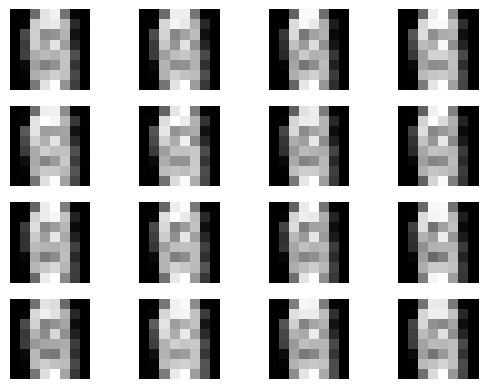

Epoch: 2, val nll=160.80729213169644
Epoch: 3, val nll=160.81976702008927
Epoch: 4, val nll=161.19442243303573
Epoch: 5, val nll=161.07995396205357
Epoch: 6, val nll=160.73770926339284
Epoch: 7, val nll=160.499970703125
saved!


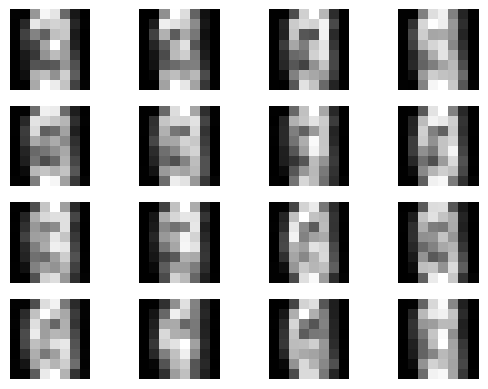

Epoch: 8, val nll=160.39032645089284
saved!


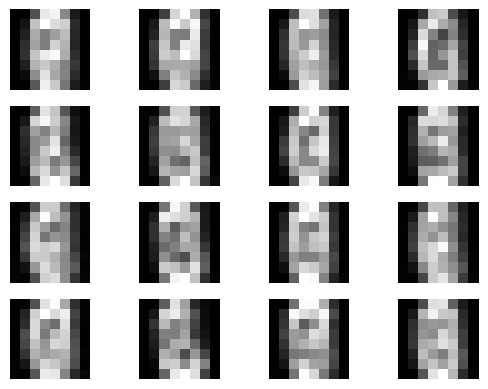

Epoch: 9, val nll=161.26369001116072
Epoch: 10, val nll=160.31924944196427
saved!


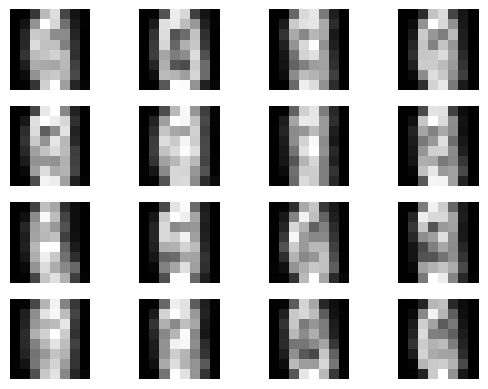

Epoch: 11, val nll=160.23338727678572
saved!


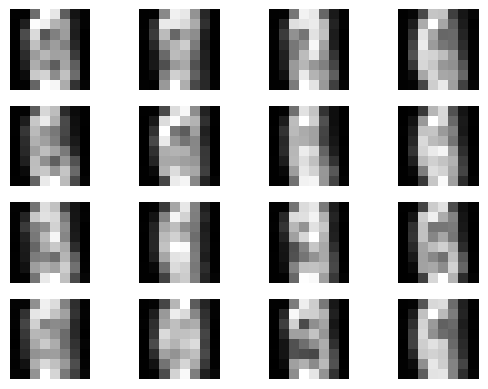

Epoch: 12, val nll=160.62834402901785
Epoch: 13, val nll=160.23707310267858
Epoch: 14, val nll=160.82795200892858
Epoch: 15, val nll=160.24845703125
Epoch: 16, val nll=160.442138671875
Epoch: 17, val nll=160.039306640625
saved!


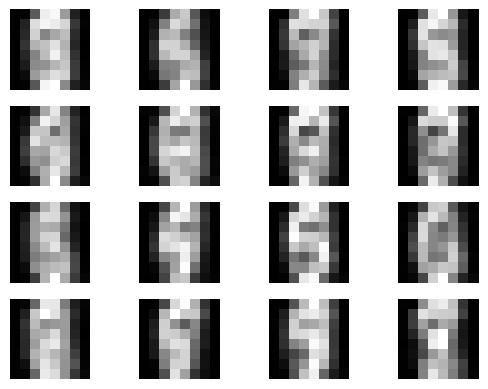

Epoch: 18, val nll=159.57906808035713
saved!


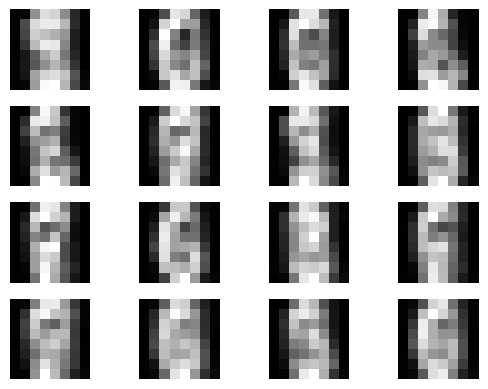

Epoch: 19, val nll=160.4394447544643
Epoch: 20, val nll=160.56662248883927
Epoch: 21, val nll=160.86381138392858
Epoch: 22, val nll=159.53565708705358
saved!


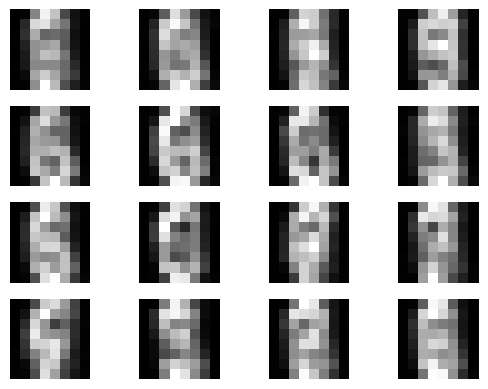

Epoch: 23, val nll=159.8866392299107
Epoch: 24, val nll=159.77116350446428
Epoch: 25, val nll=160.39808035714285
Epoch: 26, val nll=160.15277483258927
Epoch: 27, val nll=160.83439174107144
Epoch: 28, val nll=160.52794363839286
Epoch: 29, val nll=159.84873046875
Epoch: 30, val nll=160.59562639508928
Epoch: 31, val nll=159.857802734375
Epoch: 32, val nll=160.50083565848215
Epoch: 33, val nll=160.80293247767858
Epoch: 34, val nll=160.41327706473214
Epoch: 35, val nll=160.7173744419643
Epoch: 36, val nll=159.6057505580357
Epoch: 37, val nll=159.85337193080358
Epoch: 38, val nll=160.3330970982143
Epoch: 39, val nll=159.8765025111607
Epoch: 40, val nll=160.3331626674107
Epoch: 41, val nll=159.65830636160715
Epoch: 42, val nll=160.60799386160716
Epoch: 43, val nll=160.22515206473216
Epoch: 44, val nll=159.87751813616072
Epoch: 45, val nll=160.30552734375
Epoch: 46, val nll=159.81164760044643
Epoch: 47, val nll=160.30264090401786
Epoch: 48, val nll=160.51130719866072
Epoch: 49, val nll=160.310

In [13]:
# Training procedure
nll_val = training(name=result_dir + name, max_patience=max_patience, num_epochs=num_epochs, model=model, optimizer=optimizer,
                       training_loader=training_loader, val_loader=val_loader)

FINAL LOSS: nll=160.05385731263982


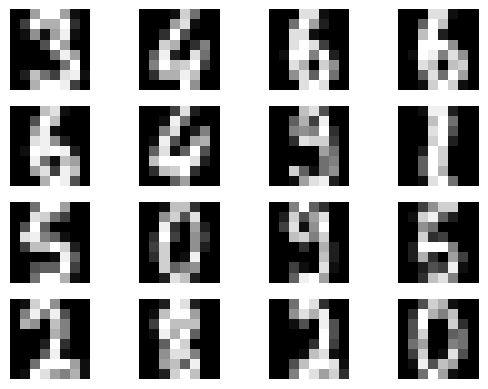

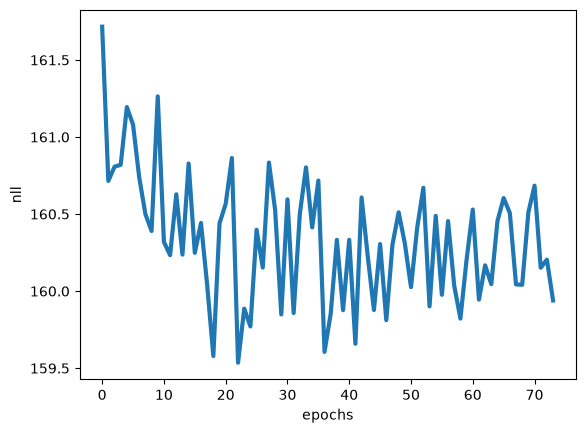

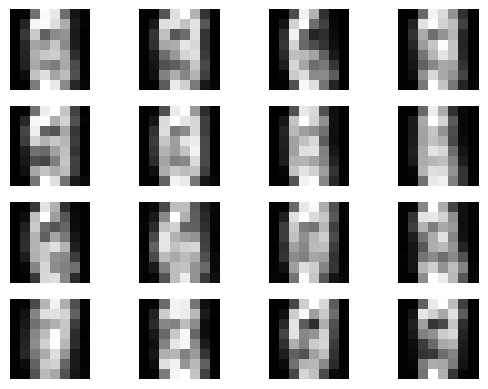

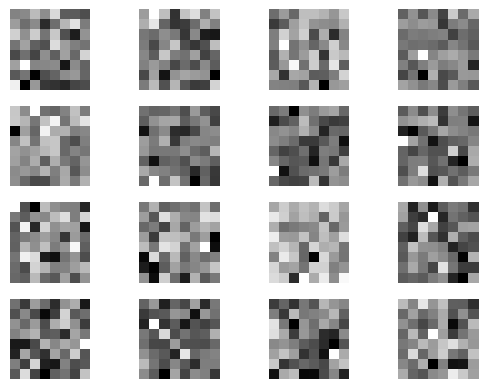

In [14]:
test_loss = evaluation(name=result_dir + name, test_loader=test_loader)
f = open(result_dir + name + '_test_loss.txt', "w")
f.write(str(test_loss))
f.close()

samples_real(result_dir + name, test_loader)

plot_curve(result_dir + name, nll_val)

samples_generated(result_dir + name, test_loader, extra_name='FINAL')
samples_diffusion(result_dir + name, test_loader, extra_name='DIFFUSION')